In [1]:
import os
from skimage import io, transform, color, img_as_ubyte
import numpy as np
from torch.utils.data import Dataset
import cv2
import torch
import torchvision.transforms as pytorch_transforms
import torch.nn.functional as F
import albumentations as A
from albumentations.pytorch.transforms import ToTensorV2

ModuleNotFoundError: No module named 'torch'

## 1. Image Dataloader Testing

In [3]:
image_path = "./ISIC - 2018/ISIC2018_Task1_Training_/ISIC_0000000"

img = io.imread(image_path+'.jpg')[:,:,:3].astype('float32')

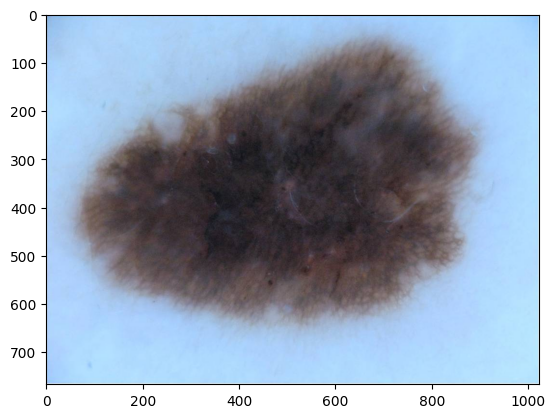

In [4]:
import matplotlib.pyplot as plt
plt.imshow(img/255)

In [5]:
img_tensor = pytorch_transforms.Compose([pytorch_transforms.ToTensor(), ])
img_tensor = img_tensor(img)

In [22]:
img_tensor.shape ## torch 的 transforms ToTensor 也会把channel提前

torch.Size([3, 767, 1022])

In [7]:
pixel_mean=torch.Tensor([123.675, 116.280, 103.530]).view(-1, 1, 1) 
pixel_std=torch.Tensor([58.395, 57.12, 57.375]).view(-1, 1, 1)

x = (img_tensor - pixel_mean) / pixel_std

In [8]:
x

tensor([[[2.1462, 1.8379, 2.0092,  ..., 1.9407, 1.9578, 2.1462],
         [1.7865, 0.8618, 0.6906,  ..., 0.9132, 1.0331, 1.9578],
         [2.0605, 0.7762, 0.3823,  ..., 0.5878, 0.7762, 1.9578],
         ...,
         [1.9920, 0.9303, 0.7762,  ..., 1.1015, 1.2214, 1.9578],
         [1.8550, 0.9988, 0.9988,  ..., 1.2728, 1.3242, 1.9578],
         [2.1804, 1.9407, 2.1462,  ..., 1.9578, 1.8893, 2.1462]],

        [[2.4286, 2.1835, 2.4286,  ..., 2.4286, 2.3410, 2.4286],
         [2.0609, 1.1856, 1.1331,  ..., 1.5182, 1.4657, 2.3060],
         [2.3585, 1.1155, 0.8179,  ..., 1.2731, 1.2906, 2.4111],
         ...,
         [2.4286, 1.4132, 1.2556,  ..., 1.8158, 1.7458, 2.4286],
         [2.2360, 1.3782, 1.3606,  ..., 1.9034, 1.7633, 2.3585],
         [2.4286, 2.2885, 2.4286,  ..., 2.4286, 2.2535, 2.4286]],

        [[2.6400, 2.5703, 2.6400,  ..., 2.6400, 2.6400, 2.6400],
         [2.4831, 1.6117, 1.6640,  ..., 2.2043, 1.9603, 2.6400],
         [2.6400, 1.6814, 1.4897,  ..., 2.0300, 1.8731, 2.

In [11]:
h, w = x.shape[-2:]

In [12]:
method = A.Compose([
    A.Resize(1024, 1024),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

In [19]:
output = method(image = img, mask = img)
print(img.shape)
print(output["image"].shape)

## albumentations -> toTensor() 自动变换维度

(767, 1022, 3)
torch.Size([3, 1024, 1024])


In [25]:
# Pad
h, w = img_tensor.shape[-2:]
padh = 1024 - h
padw = 1024 - w
print(padh, padw)
x = F.pad(img_tensor, (0, padw, 0, padh))
print(x.shape)

257 2
torch.Size([3, 1024, 1024])


C:\Users\sky31\AppData\Local\Temp\ipykernel_38836\1355396646.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  plt.imshow(np.array(x).transpose(1, 2, 0)/255)


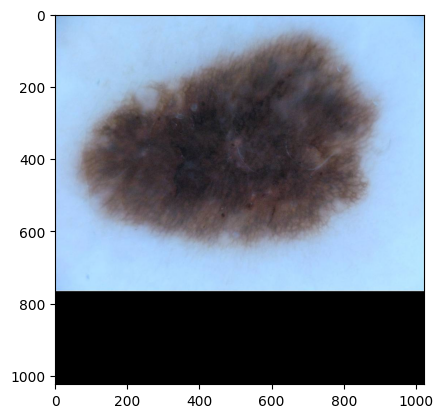

In [26]:
plt.imshow(np.array(x).transpose(1, 2, 0)/255)

In [12]:
class BinaryLoader(Dataset):
        def __init__(self, data_name, jsfiles, transforms, pixel_mean=[123.675, 116.280, 103.530], pixel_std=[58.395, 57.12, 57.375]):
            self.path = f'datasets'
            self.jsfiles = jsfiles
            self.img_tesnor = pytorch_transforms.Compose([pytorch_transforms.ToTensor(), ])
            self.transforms = transforms
            self.img_size = 1024
            self.pixel_mean = torch.Tensor(pixel_mean).view(-1, 1, 1)
            self.pixel_std = torch.Tensor(pixel_mean).view(-1, 1, 1)
            
        
        def __len__(self):
            return len(self.jsfiles)
              
        
        def __getitem__(self,idx):
            image_id = list(self.jsfiles[idx].split('.'))[0]

            image_path = os.path.join(self.path,'image_1024/',image_id)
            mask_path = os.path.join(self.path,'mask_1024/',image_id)

            modality_name = list(image_id.split('_'))[0]

            mcls = None

            if modality_name == 'ISIC':
                mcls = 0
            elif modality_name == 'CHNCXR':
                mcls = 1
            elif modality_name == 'ultra':
                mcls = 2

            if mcls is None and len(list(image_id.split('_'))) > 1:
                mcls = 3

            if mcls is None and len(modality_name) > 10:
                mcls = 4

            if mcls is None and len(modality_name) <= 10:
                mcls = 5
 
    
            img = io.imread(image_path+'.png')[:,:,:3].astype('float32')
            mask = io.imread(mask_path+'.png', as_gray=True)

            mask[mask>0]=255
            
            data_group = self.transforms(image=img, mask=mask)
            img_resized = data_group['image']
            mask = data_group['mask']

            img = self.img_tesnor(img)
            img = self.preprocess(img)
   
            return (img_resized, img, mask, image_id, mcls)
        
        def preprocess(self, x):
            """Normalize pixel values and pad to a square input."""
            # Normalize colors
            x = (x - self.pixel_mean) / self.pixel_std

            # Pad
            h, w = x.shape[-2:]
            padh = self.img_size - h
            padw = self.img_size - w
            x = F.pad(x, (0, padw, 0, padh))
            return x



## 2. Test pretrained model

In [27]:
import sys
import os
sys.path.append('./De-LightSAM-main')

### 2.1 Model Parameter Testing

In [75]:
pretrain_dict_cvccdb = torch.load("./checkpoint/ESP_cvccdb_best.pth")
pretrain_dict_isic = torch.load("./checkpoint/ESP_isic_best.pth")
pretrain_dict_lung = torch.load("./checkpoint/ESP_lung_best.pth")

In [76]:
## 模型参数完全一致
pretrain_dict_cvccdb.keys() == pretrain_dict_isic.keys() == pretrain_dict_lung.keys()

True

In [77]:
## 模型参数数量
for x, y, z in zip(pretrain_dict_cvccdb.values(), pretrain_dict_isic.values(), pretrain_dict_lung.values()):
    assert x.shape == y.shape == z.shape, "Different"
else:
    print("参数形状完全一致")

参数形状完全一致


In [78]:
## 相同变量与不同变量
same_p = []
different_p = []

for (x_key, x_val), (y_key, y_val), (z_key, z_val) in zip(
    pretrain_dict_cvccdb.items(), 
    pretrain_dict_isic.items(), 
    pretrain_dict_lung.items()
):
    # 检查张量是否完全相等
    if torch.all(x_val == y_val) and torch.all(y_val == z_val):
        same_p.append(x_key)
    else:
        different_p.append(x_key)

In [44]:
print("相同张量数量: %d; 不同张量数量: %d"%(len(same_p), len(different_p)))

相同张量数量: 424; 不同张量数量: 80


In [ ]:
ESP, ESP_no_med = [], []
ESP_encoder, med_encoder, med_not_vit = 0, 0, 0

## 训练好的模型
pretrain_dict = torch.load("./checkpoint/ESP_cvccdb_best.pth")
for n, value in pretrain_dict.items():
    ESP.append(n)
    if "SemiTViT" in n:
        ESP_encoder += 1
        if "med" not in n:
            ESP_no_med.append(n)
    if "med" in n:
        med_encoder += 1
    if "SemiTViT" not in n and "med" in n:
        med_not_vit += 1

print("SemitViT parameters: ", ESP_encoder) # 382
print("med parameters: ", med_encoder) # 80
print("med not SemitViT parameters: ", med_not_vit) # 0

## Model中，所有自定义参数(包含med)均来自于SemiTViT, 且只有与med相关的变量参与反向传播

### 2.2 Compared with Mobile SAM

In [67]:
pretrain_dict_cvccdb = torch.load("./checkpoint/ESP_cvccdb_best.pth")
pretrain_dict_mobile = torch.load("./De-LightSAM-main/pretrain/mobile_sam.pt")

same_p = []
different_p = []
not_in = []
for (x_key, x_val) in pretrain_dict_cvccdb.items():

    key = x_key.replace("SemiTViT", "image_encoder")
    output = pretrain_dict_mobile.get(key, "no")
    if not isinstance(output, str):
        # 检查张量是否完全相等
        if torch.all(x_val == output):
            same_p.append(x_key)
        else:
            different_p.append(x_key)
    else:
        not_in.append(x_key)

In [84]:
## 看起来 mask_decoder 被训练过 ？
# different_p

In [63]:
not_in

['SemiTViT.patch_embed.seq.0.c.weight',
 'SemiTViT.patch_embed.seq.0.bn.weight',
 'SemiTViT.patch_embed.seq.0.bn.bias',
 'SemiTViT.patch_embed.seq.0.bn.running_mean',
 'SemiTViT.patch_embed.seq.0.bn.running_var',
 'SemiTViT.patch_embed.seq.0.bn.num_batches_tracked',
 'SemiTViT.patch_embed.seq.2.c.weight',
 'SemiTViT.patch_embed.seq.2.bn.weight',
 'SemiTViT.patch_embed.seq.2.bn.bias',
 'SemiTViT.patch_embed.seq.2.bn.running_mean',
 'SemiTViT.patch_embed.seq.2.bn.running_var',
 'SemiTViT.patch_embed.seq.2.bn.num_batches_tracked',
 'SemiTViT.layers.0.blocks.0.conv1.c.weight',
 'SemiTViT.layers.0.blocks.0.conv1.bn.weight',
 'SemiTViT.layers.0.blocks.0.conv1.bn.bias',
 'SemiTViT.layers.0.blocks.0.conv1.bn.running_mean',
 'SemiTViT.layers.0.blocks.0.conv1.bn.running_var',
 'SemiTViT.layers.0.blocks.0.conv1.bn.num_batches_tracked',
 'SemiTViT.layers.0.blocks.0.conv2.c.weight',
 'SemiTViT.layers.0.blocks.0.conv2.bn.weight',
 'SemiTViT.layers.0.blocks.0.conv2.bn.bias',
 'SemiTViT.layers.0.block

In [55]:
pretrain_dict_cvccdb['mask_decoder.transformer.layers.0.self_attn.q_proj.weight']

tensor([[-8.4931e-02, -1.3810e-01,  8.0805e-02,  ..., -1.3787e-04,
         -1.9996e-02, -1.5854e-03],
        [-4.0670e-02, -1.2327e-01,  6.2240e-03,  ...,  1.6338e-02,
         -3.5475e-02,  5.1099e-02],
        [-2.9817e-02,  5.4978e-02,  4.9566e-02,  ..., -1.1634e-02,
         -7.3502e-02,  1.1480e-01],
        ...,
        [ 4.6036e-02,  1.3815e-02, -6.0206e-02,  ...,  6.6244e-03,
          2.1135e-02, -1.0492e-02],
        [ 6.0682e-02,  2.0198e-02, -4.2824e-03,  ...,  2.9002e-02,
          4.0112e-02, -3.5340e-02],
        [ 1.1588e-02, -1.0304e-02,  3.7427e-02,  ..., -1.6347e-03,
         -2.7075e-04,  2.0400e-02]])

In [56]:
pretrain_dict_mobile['mask_decoder.transformer.layers.0.self_attn.q_proj.weight']

tensor([[-0.0879, -0.1321,  0.0836,  ...,  0.0004, -0.0185,  0.0011],
        [-0.0375, -0.1283,  0.0036,  ...,  0.0273, -0.0380,  0.0483],
        [-0.0320,  0.0465,  0.0535,  ..., -0.0090, -0.0755,  0.1173],
        ...,
        [ 0.0465,  0.0303, -0.0648,  ...,  0.0008,  0.0163, -0.0158],
        [ 0.0622,  0.0186, -0.0068,  ...,  0.0297,  0.0375, -0.0383],
        [ 0.0084, -0.0070,  0.0405,  ..., -0.0055,  0.0015,  0.0230]])

In [49]:
len(not_in)

393

In [40]:
ESP, ESP_no_med = [], []
ESP_encoder, med_encoder, med_not_vit = 0, 0, 0

## 训练好的模型
pretrain_dict_cvccdb = torch.load("./checkpoint/ESP_cvccdb_best.pth")
pretrain_dict_mobile = torch.load("./De-LightSAM-main/pretrain/mobile_sam.pt")
for n, value in pretrain_dict.items():
    ESP.append(n)
    if "SemiTViT" in n:
        ESP_encoder += 1
        if "med" not in n:
            ESP_no_med.append(n)
    if "med" in n:
        med_encoder += 1
    if "SemiTViT" not in n and "med" in n:
        med_not_vit += 1

print("SemitViT parameters: ", ESP_encoder)
print("med parameters: ", med_encoder)
print("med not SemitViT parameters: ", med_not_vit)

SemitViT parameters:  382
med parameters:  80
med not SemitViT parameters:  0


In [15]:
mobile = []
encoder = 0
pretrain_dict = torch.load("./De-LightSAM-main/pretrain/mobile_sam.pt")
for n, value in pretrain_dict.items():
    if "image_encoder" in n:
        encoder += 1
        mobile.append(n)
print("mobile_sam parameters: ", encoder)

mobile_sam parameters:  302


In [16]:
len(ESP_no_med)

302

In [17]:
len(mobile)

302

In [18]:
count = 0
for x, y in zip(ESP_no_med, mobile):
    if x.split(".")[1:] == y.split(".")[1:]:
        print(x)
        print(y)
        print()
        count += 1

SemiTViT.patch_embed.seq.0.c.weight
image_encoder.patch_embed.seq.0.c.weight

SemiTViT.patch_embed.seq.0.bn.weight
image_encoder.patch_embed.seq.0.bn.weight

SemiTViT.patch_embed.seq.0.bn.bias
image_encoder.patch_embed.seq.0.bn.bias

SemiTViT.patch_embed.seq.0.bn.running_mean
image_encoder.patch_embed.seq.0.bn.running_mean

SemiTViT.patch_embed.seq.0.bn.running_var
image_encoder.patch_embed.seq.0.bn.running_var

SemiTViT.patch_embed.seq.0.bn.num_batches_tracked
image_encoder.patch_embed.seq.0.bn.num_batches_tracked

SemiTViT.patch_embed.seq.2.c.weight
image_encoder.patch_embed.seq.2.c.weight

SemiTViT.patch_embed.seq.2.bn.weight
image_encoder.patch_embed.seq.2.bn.weight

SemiTViT.patch_embed.seq.2.bn.bias
image_encoder.patch_embed.seq.2.bn.bias

SemiTViT.patch_embed.seq.2.bn.running_mean
image_encoder.patch_embed.seq.2.bn.running_mean

SemiTViT.patch_embed.seq.2.bn.running_var
image_encoder.patch_embed.seq.2.bn.running_var

SemiTViT.patch_embed.seq.2.bn.num_batches_tracked
image_encode

In [19]:
encoder

302

In [20]:
count

302

In [21]:
ESP_encoder

382

In [22]:
from model import ESPMedSAM
model = ESPMedSAM()

C:\ProgramData\miniconda3\Lib\site-packages\timm\models\registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


LR SCALES: [0.08589934592000005, 0.10737418240000006, 0.13421772800000006, 0.1677721600000001, 0.20971520000000007, 0.2621440000000001, 0.3276800000000001, 0.4096000000000001, 0.5120000000000001, 0.6400000000000001, 0.8, 1.0]
Initializing ImageEncoderViT


In [24]:
model_image_encoder = []
for n, value in model.image_encoder.named_parameters():
    model_image_encoder.append(n)